In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load dataset
data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# Convert target variable
data["Churn"] = data["Churn"].map({
    "Yes": 1,
    "No": 0
})

# Remove customer ID
data = data.drop(columns=["customerID"])

# Separate features and target
X = data.drop(columns=["Churn"])
y = data["Churn"]

print("Dataset shape:", data.shape)
print("Features:", X.shape)
print("Target:", y.shape)

Dataset shape: (7043, 20)
Features: (7043, 19)
Target: (7043,)


In [3]:
# Identify feature types

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\aatik\AppData\Local\Temp\ipykernel_15704\1880558097.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [4]:
# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [5]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 19)
Testing data: (1409, 19)


In [6]:
# Create the Random Forest pipeline

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

print("Random Forest pipeline created successfully!")

Random Forest pipeline created successfully!


In [7]:
# Train the baseline pipeline

rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_precision = precision_score(y_test, y_pred)
baseline_recall = recall_score(y_test, y_pred)
baseline_f1 = f1_score(y_test, y_pred)
baseline_roc_auc = roc_auc_score(y_test, y_prob)

print("Baseline Pipeline Performance")
print("-----------------------------")
print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"F1 Score:  {baseline_f1:.4f}")
print(f"ROC-AUC:   {baseline_roc_auc:.4f}")

Baseline Pipeline Performance
-----------------------------
Accuracy:  0.7779
Precision: 0.6034
Recall:    0.4759
F1 Score:  0.5321
ROC-AUC:   0.8162


In [9]:
# Hyperparameter tuning for the complete pipeline

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation accuracy:")
print(f"{grid_search.best_score_:.4f}")

Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best cross-validation accuracy:
0.8017


In [10]:
# Evaluate the optimized pipeline on the unseen test set

best_pipeline = grid_search.best_estimator_

y_pred_tuned = best_pipeline.predict(X_test)
y_prob_tuned = best_pipeline.predict_proba(X_test)[:, 1]

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_roc_auc = roc_auc_score(y_test, y_prob_tuned)

print("Optimized Pipeline Performance")
print("------------------------------")
print(f"Accuracy:  {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall:    {tuned_recall:.4f}")
print(f"F1 Score:  {tuned_f1:.4f}")
print(f"ROC-AUC:   {tuned_roc_auc:.4f}")

Optimized Pipeline Performance
------------------------------
Accuracy:  0.8041
Precision: 0.6667
Recall:    0.5241
F1 Score:  0.5868
ROC-AUC:   0.8413


In [11]:
# Compare baseline and optimized pipeline

performance_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Baseline Pipeline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc
    ],
    "Optimized Pipeline": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1,
        tuned_roc_auc
    ]
})

print(performance_comparison)

      Metric  Baseline Pipeline  Optimized Pipeline
0   Accuracy           0.777857            0.804116
1  Precision           0.603390            0.666667
2     Recall           0.475936            0.524064
3   F1 Score           0.532138            0.586826
4    ROC-AUC           0.816159            0.841279


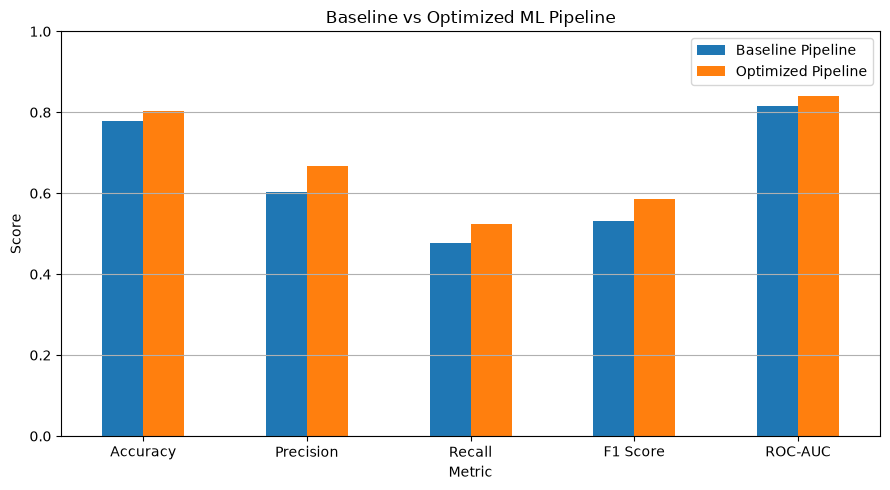

In [12]:
# Visualize performance comparison

performance_plot = performance_comparison.set_index("Metric")

performance_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Baseline vs Optimized ML Pipeline")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.tight_layout()
plt.savefig(
    "pipeline_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# Calculate performance improvement

performance_comparison["Improvement"] = (
    performance_comparison["Optimized Pipeline"]
    - performance_comparison["Baseline Pipeline"]
)

# Save final performance report
performance_comparison.to_csv(
    "final_pipeline_performance_report.csv",
    index=False
)

print("Final performance report saved successfully!")
print(performance_comparison)

Final performance report saved successfully!
      Metric  Baseline Pipeline  Optimized Pipeline  Improvement
0   Accuracy           0.777857            0.804116     0.026260
1  Precision           0.603390            0.666667     0.063277
2     Recall           0.475936            0.524064     0.048128
3   F1 Score           0.532138            0.586826     0.054689
4    ROC-AUC           0.816159            0.841279     0.025119


In [14]:
# Save the best hyperparameters

best_parameters = pd.DataFrame(
    list(grid_search.best_params_.items()),
    columns=["Parameter", "Best Value"]
)

best_parameters.to_csv(
    "optimized_pipeline_parameters.csv",
    index=False
)

print("Best parameters saved successfully!")
print(best_parameters)

Best parameters saved successfully!
                  Parameter  Best Value
0          model__max_depth          10
1   model__min_samples_leaf           2
2  model__min_samples_split           5
3       model__n_estimators         200


In [15]:
print("Engineering Trade-offs")
print("-" * 30)

print("""
1. Preprocessing:
   Numerical features were imputed and standardized.
   Categorical features were imputed and One-Hot Encoded.

2. Reproducibility:
   All preprocessing and model steps are contained inside one Pipeline.

3. Validation:
   5-fold cross-validation was used during hyperparameter tuning.

4. Optimization:
   GridSearchCV tested multiple Random Forest configurations.

5. Computational Cost:
   Cross-validation and hyperparameter tuning require more computation
   than training a single default model.

6. Generalization:
   The final optimized pipeline was evaluated on an unseen test set.

7. Maintainability:
   Keeping preprocessing and modeling together reduces the risk of
   applying inconsistent transformations to future data.
""")

Engineering Trade-offs
------------------------------

1. Preprocessing:
   Numerical features were imputed and standardized.
   Categorical features were imputed and One-Hot Encoded.

2. Reproducibility:
   All preprocessing and model steps are contained inside one Pipeline.

3. Validation:
   5-fold cross-validation was used during hyperparameter tuning.

4. Optimization:
   GridSearchCV tested multiple Random Forest configurations.

5. Computational Cost:
   Cross-validation and hyperparameter tuning require more computation
   than training a single default model.

6. Generalization:
   The final optimized pipeline was evaluated on an unseen test set.

7. Maintainability:
   Keeping preprocessing and modeling together reduces the risk of
   applying inconsistent transformations to future data.



In [16]:
week4_reflection = """
WEEK 4 OPTIMIZATION REFLECTION
==============================

During Week 4, I focused on improving machine learning model reliability,
performance, and generalization.

I worked with feature encoding, feature selection, PCA, cross-validation,
hyperparameter tuning, and the bias-variance tradeoff.

For Day 28, I combined preprocessing, model training, cross-validation,
and hyperparameter tuning into a single reproducible machine learning
pipeline.

The pipeline automatically handles numerical and categorical features
before training the Random Forest model. GridSearchCV was then used to
search for suitable hyperparameters using 5-fold cross-validation.

The optimized pipeline was evaluated on an unseen test set and compared
with the baseline pipeline using Accuracy, Precision, Recall, F1 Score,
and ROC-AUC.

Key engineering trade-offs included increased computational cost from
cross-validation and hyperparameter tuning versus improved and more
reliable model evaluation.

The main learning from Week 4 is that a production-oriented machine
learning workflow should be reproducible, validated, maintainable, and
carefully optimized rather than relying only on a single model training
step.

Overall, Week 4 helped me understand how preprocessing, validation,
feature engineering, model complexity, and optimization can be combined
into a complete machine learning workflow.
"""

print(week4_reflection)


WEEK 4 OPTIMIZATION REFLECTION

During Week 4, I focused on improving machine learning model reliability,
performance, and generalization.

I worked with feature encoding, feature selection, PCA, cross-validation,
hyperparameter tuning, and the bias-variance tradeoff.

For Day 28, I combined preprocessing, model training, cross-validation,
and hyperparameter tuning into a single reproducible machine learning
pipeline.

The pipeline automatically handles numerical and categorical features
before training the Random Forest model. GridSearchCV was then used to
search for suitable hyperparameters using 5-fold cross-validation.

The optimized pipeline was evaluated on an unseen test set and compared
with the baseline pipeline using Accuracy, Precision, Recall, F1 Score,
and ROC-AUC.

Key engineering trade-offs included increased computational cost from
cross-validation and hyperparameter tuning versus improved and more
reliable model evaluation.

The main learning from Week 4 is that a pro